In [1]:
# ============================================================
# TFG - Modelo de Alerta Temprana para Anticipar Recesiones
# en EE.UU. mediante Indicadores Macroeconómicos
# Autor: Juan Diez de Rivera de Solís
# UFV Madrid - Grado en Business Analytics - 2025/2026
# ============================================================
# NOTEBOOK 1: INGENIERÍA DEL DATO (ETL)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

print("✅ Librerías cargadas correctamente")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

✅ Librerías cargadas correctamente
Pandas version: 2.0.3
Numpy version: 1.24.3


In [2]:
# ============================================================
# CELDA 2: CARGA DE DATOS BRUTOS (EXTRACCIÓN)
# ============================================================

# Definimos la ruta de los archivos
path = ""  # Los CSV están en la misma carpeta que el notebook

# Carga de cada serie con su nombre descriptivo
cpi    = pd.read_csv("CPIAUCSL.csv", parse_dates=["observation_date"])
gdp    = pd.read_csv("GDPC1.csv",    parse_dates=["observation_date"])
houst  = pd.read_csv("HOUST.csv",    parse_dates=["observation_date"])
rsafs  = pd.read_csv("RSAFS.csv",   parse_dates=["observation_date"])
t10y2y = pd.read_csv("T10Y2Y.csv",  parse_dates=["observation_date"])
umcsent= pd.read_csv("UMCSENT.csv", parse_dates=["observation_date"])
unrate = pd.read_csv("UNRATE.csv",  parse_dates=["observation_date"])
usrec  = pd.read_csv("USREC.csv",   parse_dates=["observation_date"])

# Renombramos la columna de fecha en todas
dfs = {
    "CPI (Inflación)":           cpi,
    "GDP (PIB Real)":            gdp,
    "HOUST (Housing Starts)":    houst,
    "RSAFS (Ventas Minoristas)": rsafs,
    "T10Y2Y (Curva de Tipos)":   t10y2y,
    "UMCSENT (Conf. Consumidor)":umcsent,
    "UNRATE (Desempleo)":        unrate,
    "USREC (Recesión)":          usrec
}

# Tabla de datos iniciales con tipos
print("=" * 60)
print("TABLA DE DATOS INICIALES")
print("=" * 60)
for nombre, df in dfs.items():
    print(f"\n📊 {nombre}")
    print(f"   Filas: {len(df)} | Rango: {df['observation_date'].min().date()} → {df['observation_date'].max().date()}")
    print(f"   Columnas: {list(df.columns)}")
    print(f"   Tipos: {df.dtypes.to_dict()}")
    print(f"   Nulos: {df.isnull().sum().to_dict()}")

print("\n✅ Todos los CSV cargados correctamente")

TABLA DE DATOS INICIALES

📊 CPI (Inflación)
   Filas: 944 | Rango: 1947-01-01 → 2025-08-01
   Columnas: ['observation_date', 'CPIAUCSL']
   Tipos: {'observation_date': dtype('<M8[ns]'), 'CPIAUCSL': dtype('float64')}
   Nulos: {'observation_date': 0, 'CPIAUCSL': 0}

📊 GDP (PIB Real)
   Filas: 314 | Rango: 1947-01-01 → 2025-04-01
   Columnas: ['observation_date', 'GDPC1']
   Tipos: {'observation_date': dtype('<M8[ns]'), 'GDPC1': dtype('float64')}
   Nulos: {'observation_date': 0, 'GDPC1': 0}

📊 HOUST (Housing Starts)
   Filas: 800 | Rango: 1959-01-01 → 2025-08-01
   Columnas: ['observation_date', 'HOUST']
   Tipos: {'observation_date': dtype('<M8[ns]'), 'HOUST': dtype('int64')}
   Nulos: {'observation_date': 0, 'HOUST': 0}

📊 RSAFS (Ventas Minoristas)
   Filas: 404 | Rango: 1992-01-01 → 2025-08-01
   Columnas: ['observation_date', 'RSAFS']
   Tipos: {'observation_date': dtype('<M8[ns]'), 'RSAFS': dtype('int64')}
   Nulos: {'observation_date': 0, 'RSAFS': 0}

📊 T10Y2Y (Curva de Tipos)
   

In [3]:
# ============================================================
# CELDA 3: TRANSFORMACIÓN - LIMPIEZA Y HOMOGENEIZACIÓN
# ============================================================

# --- Paso 1: Estandarizar nombre de columna fecha ---
for nombre, df in dfs.items():
    df.rename(columns={"observation_date": "fecha"}, inplace=True)
    df.set_index("fecha", inplace=True)

# --- Paso 2: GDPC1 trimestral → mensual (interpolación) ---
gdp = gdp.resample("MS").interpolate(method="linear")
print(f"✅ GDP interpolado a mensual: {len(gdp)} filas")

# --- Paso 3: Recortar todas las series al rango común ---
inicio = "1992-01-01"
fin    = "2025-08-01"

cpi     = cpi.loc[inicio:fin]
gdp     = gdp.loc[inicio:fin]
houst   = houst.loc[inicio:fin]
rsafs   = rsafs.loc[inicio:fin]
t10y2y  = t10y2y.loc[inicio:fin]
umcsent = umcsent.loc[inicio:fin]
unrate  = unrate.loc[inicio:fin]
usrec   = usrec.loc[inicio:fin]

# --- Paso 4: Tratar nulos UMCSENT ---
umcsent["UMCSENT"] = umcsent["UMCSENT"].interpolate(method="linear")
print(f"✅ Nulos UMCSENT tras interpolación: {umcsent.isnull().sum().values[0]}")

# --- Paso 5: Merge de todas las series en un único DataFrame ---
df_final = pd.concat([
    cpi, gdp, houst, rsafs, t10y2y, umcsent, unrate, usrec
], axis=1)

# --- Paso 6: Verificación ---
print(f"\n{'='*60}")
print(f"DATASET FINAL UNIFICADO")
print(f"{'='*60}")
print(f"Dimensiones: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"Rango: {df_final.index.min().date()} → {df_final.index.max().date()}")
print(f"\nColumnas y tipos:")
print(df_final.dtypes)
print(f"\nNulos por columna:")
print(df_final.isnull().sum())
print(f"\nPrimeras filas:")
print(df_final.head())

✅ GDP interpolado a mensual: 940 filas
✅ Nulos UMCSENT tras interpolación: 0

DATASET FINAL UNIFICADO
Dimensiones: 404 filas × 8 columnas
Rango: 1992-01-01 → 2025-08-01

Columnas y tipos:
CPIAUCSL    float64
GDPC1       float64
HOUST         int64
RSAFS         int64
T10Y2Y      float64
UMCSENT     float64
UNRATE      float64
USREC         int64
dtype: object

Nulos por columna:
CPIAUCSL    0
GDPC1       4
HOUST       0
RSAFS       0
T10Y2Y      0
UMCSENT     0
UNRATE      0
USREC       0
dtype: int64

Primeras filas:
            CPIAUCSL         GDPC1  HOUST   RSAFS  T10Y2Y  UMCSENT  UNRATE  \
fecha                                                                        
1992-01-01     138.3  10236.435000   1176  159177    2.07     67.5     7.3   
1992-02-01     138.6  10273.433000   1250  159189    2.13     68.8     7.4   
1992-03-01     139.1  10310.431000   1297  158647    1.86     76.0     7.4   
1992-04-01     139.4  10347.429000   1099  159921    2.14     77.2     7.4   
1992-05-

In [5]:
# ============================================================
# CELDA 4: LIMPIEZA FINAL Y CARGA EN BASE DE DATOS (SQLite)
# ============================================================

# --- Paso 1: Resolver los 4 nulos restantes de GDPC1 ---
df_final["GDPC1"] = df_final["GDPC1"].interpolate(method="linear")
print(f"✅ Nulos GDPC1 tras interpolación: {df_final['GDPC1'].isnull().sum()}")
print(f"✅ Nulos totales en dataset: {df_final.isnull().sum().sum()}")

# --- Paso 2: Tabla de datos finales con tipos ---
print(f"\n{'='*60}")
print("TABLA DE DATOS FINALES")
print(f"{'='*60}")
resumen = pd.DataFrame({
    "Variable": df_final.columns,
    "Tipo":     df_final.dtypes.values,
    "Nulos":    df_final.isnull().sum().values,
    "Min":      df_final.min().values.round(2),
    "Max":      df_final.max().values.round(2),
    "Media":    df_final.mean().values.round(2)
})
print(resumen.to_string(index=False))

# --- Paso 3: Guardar en SQLite ---
conn = sqlite3.connect("tfg_recesiones.db")
df_final.to_sql("macroeconomicos", conn, if_exists="replace", index=True)
conn.close()
print(f"\n✅ Dataset guardado en SQLite: tfg_recesiones.db")
print(f"   Tabla: 'macroeconomicos'")
print(f"   Dimensiones finales: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")

# --- Paso 4: Verificar que se guardó correctamente ---
conn = sqlite3.connect("tfg_recesiones.db")
df_verificacion = pd.read_sql("SELECT * FROM macroeconomicos LIMIT 3", conn)
conn.close()
print(f"\n✅ Verificación lectura desde SQLite:")
print(df_verificacion)

✅ Nulos GDPC1 tras interpolación: 0
✅ Nulos totales en dataset: 0

TABLA DE DATOS FINALES
Variable    Tipo  Nulos       Min       Max     Media
CPIAUCSL float64      0    138.30    323.36    213.69
   GDPC1 float64      0  10236.44  23770.98  16706.42
   HOUST   int64      0    478.00   2273.00   1338.82
   RSAFS   int64      0 158647.00 732010.00 378149.90
  T10Y2Y float64      0     -0.93      2.83      1.02
 UMCSENT float64      0     50.00    112.00     85.05
  UNRATE float64      0      3.40     14.80      5.65
   USREC   int64      0      0.00      1.00      0.07

✅ Dataset guardado en SQLite: tfg_recesiones.db
   Tabla: 'macroeconomicos'
   Dimensiones finales: 404 filas × 8 columnas

✅ Verificación lectura desde SQLite:
                 fecha  CPIAUCSL      GDPC1  HOUST   RSAFS  T10Y2Y  UMCSENT  \
0  1992-01-01 00:00:00     138.3  10236.435   1176  159177    2.07     67.5   
1  1992-02-01 00:00:00     138.6  10273.433   1250  159189    2.13     68.8   
2  1992-03-01 00:00:00   

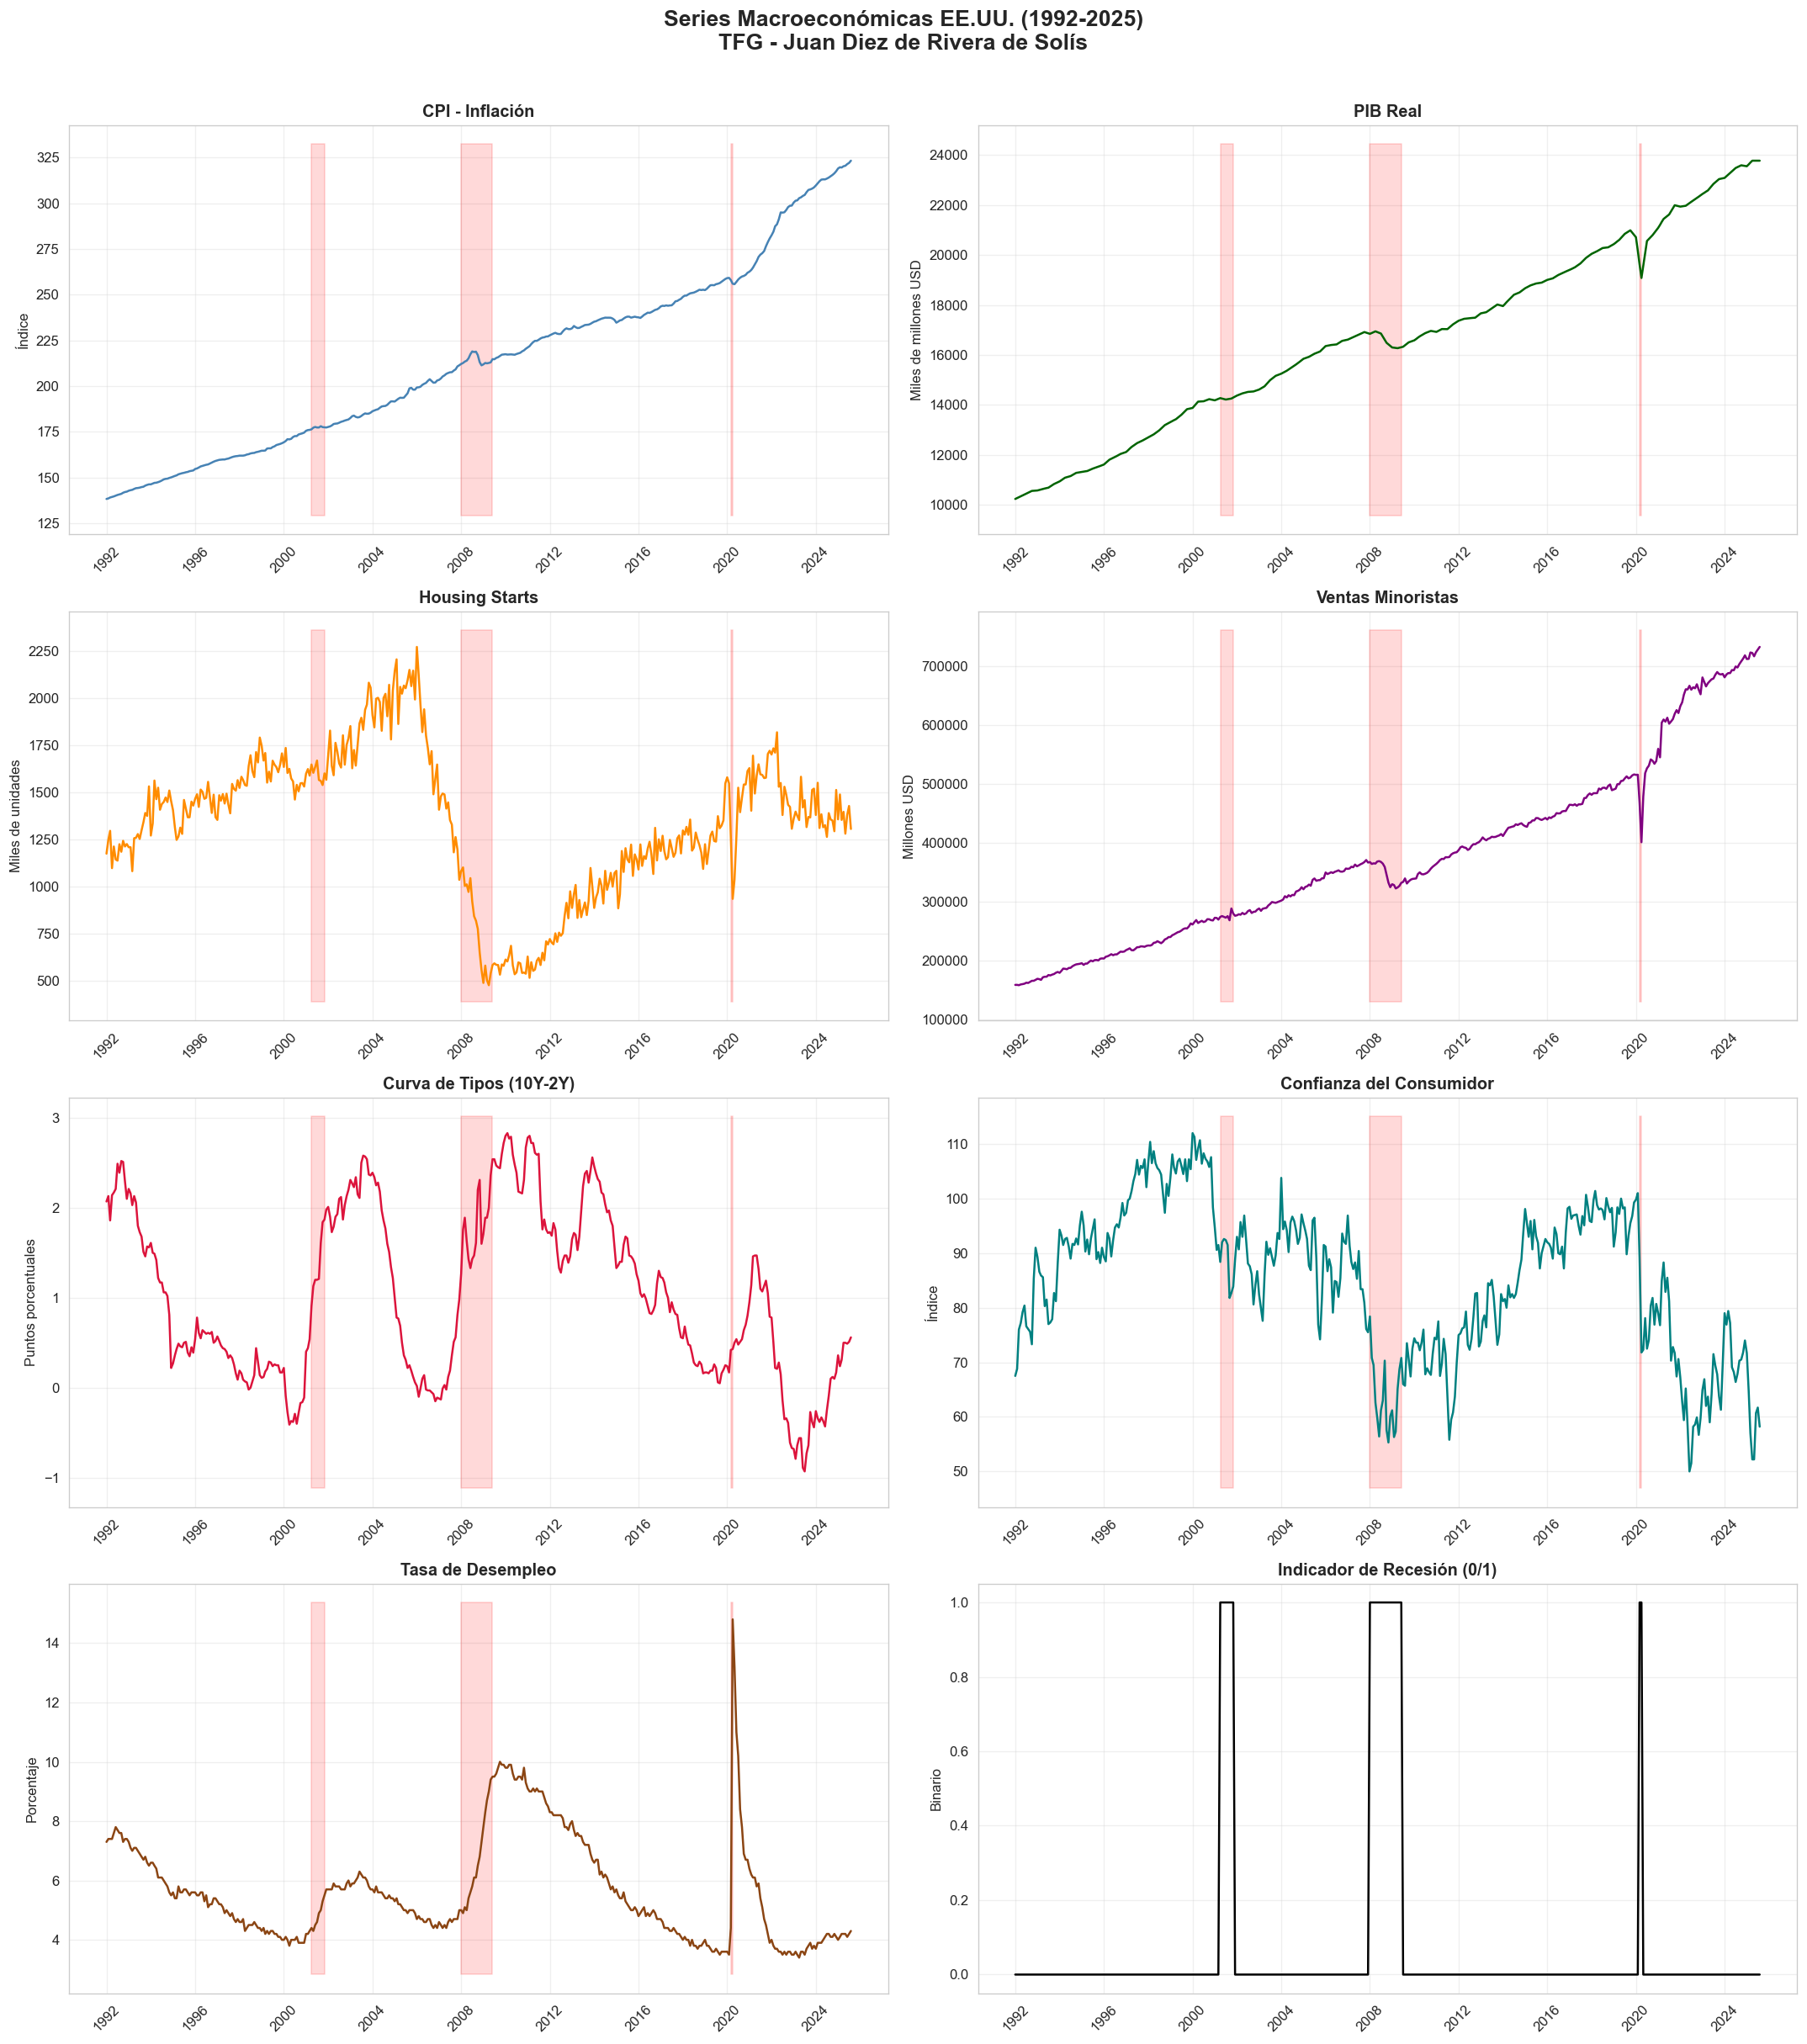

✅ Gráfico guardado como 01_series_temporales.png


In [6]:
# ============================================================
# CELDA 5: VISUALIZACIÓN DE LAS SERIES TEMPORALES
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle("Series Macroeconómicas EE.UU. (1992-2025)\nTFG - Juan Diez de Rivera de Solís",
             fontsize=16, fontweight="bold", y=1.01)

# Definimos colores y metadatos de cada serie
series_info = [
    ("CPIAUCSL", "CPI - Inflación",              "steelblue",   "Índice"),
    ("GDPC1",    "PIB Real",                      "darkgreen",   "Miles de millones USD"),
    ("HOUST",    "Housing Starts",                "darkorange",  "Miles de unidades"),
    ("RSAFS",    "Ventas Minoristas",             "purple",      "Millones USD"),
    ("T10Y2Y",   "Curva de Tipos (10Y-2Y)",       "crimson",     "Puntos porcentuales"),
    ("UMCSENT",  "Confianza del Consumidor",      "teal",        "Índice"),
    ("UNRATE",   "Tasa de Desempleo",             "saddlebrown", "Porcentaje"),
    ("USREC",    "Indicador de Recesión (0/1)",   "black",       "Binario"),
]

for ax, (col, titulo, color, unidad) in zip(axes.flatten(), series_info):
    ax.plot(df_final.index, df_final[col], color=color, linewidth=1.5)
    
    # Sombreamos periodos de recesión en todas las gráficas
    if col != "USREC":
        recesion = df_final["USREC"] == 1
        ax.fill_between(df_final.index, ax.get_ylim()[0], ax.get_ylim()[1],
                       where=recesion, alpha=0.15, color="red", label="Recesión")
    
    ax.set_title(titulo, fontweight="bold", fontsize=12)
    ax.set_ylabel(unidad, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("01_series_temporales.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado como 01_series_temporales.png")

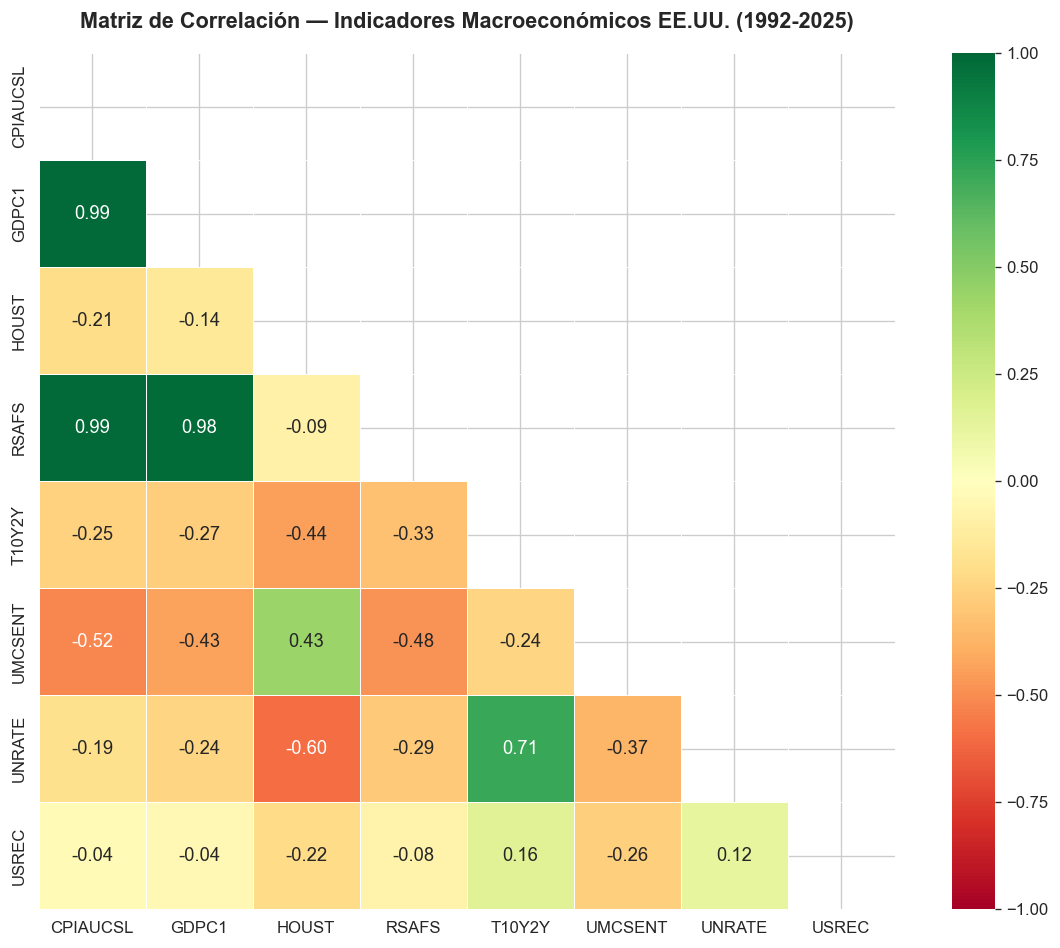

✅ Matriz de correlación guardada como 02_matriz_correlacion.png

📊 Correlación de cada variable con USREC (recesión):
UMCSENT    -0.262
HOUST      -0.215
T10Y2Y      0.163
UNRATE      0.119
RSAFS      -0.081
GDPC1      -0.044
CPIAUCSL   -0.038
Name: USREC, dtype: float64


In [7]:
# ============================================================
# CELDA 6: MATRIZ DE CORRELACIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Calculamos correlaciones (excluimos USREC para la matriz principal)
correlacion = df_final.corr(method="pearson")

# Máscara para el triángulo superior
mask = np.triu(np.ones_like(correlacion, dtype=bool))

# Mapa de calor
sns.heatmap(
    correlacion,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 11}
)

ax.set_title("Matriz de Correlación — Indicadores Macroeconómicos EE.UU. (1992-2025)",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("02_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Matriz de correlación guardada como 02_matriz_correlacion.png")

# Correlaciones con USREC ordenadas
print("\n📊 Correlación de cada variable con USREC (recesión):")
corr_usrec = correlacion["USREC"].drop("USREC").sort_values(key=abs, ascending=False)
print(corr_usrec.round(3))

In [8]:
# ============================================================
# CELDA 7: EXPORTACIÓN DEL DATASET FINAL
# ============================================================

# Exportamos a CSV para usar en los siguientes notebooks
df_final.to_csv("dataset_final.csv")
print("✅ Dataset exportado como dataset_final.csv")

# Resumen final del ETL
print(f"\n{'='*60}")
print("RESUMEN FINAL DEL PROCESO ETL")
print(f"{'='*60}")
print(f"• Fuentes originales:     8 series de FRED/NBER")
print(f"• Rango temporal:         1992-01-01 → 2025-08-01")
print(f"• Observaciones finales:  {len(df_final)} filas mensuales")
print(f"• Variables:              {df_final.shape[1]} indicadores")
print(f"• Nulos en dataset final: {df_final.isnull().sum().sum()}")
print(f"• Recesiones en muestra:  {df_final['USREC'].sum()} meses ({df_final['USREC'].mean()*100:.1f}%)")
print(f"• Archivos generados:")
print(f"   - tfg_recesiones.db        (base de datos SQLite)")
print(f"   - dataset_final.csv        (dataset unificado)")
print(f"   - 01_series_temporales.png (visualización series)")
print(f"   - 02_matriz_correlacion.png(matriz de correlación)")
print(f"\n✅ ETL completado exitosamente")

✅ Dataset exportado como dataset_final.csv

RESUMEN FINAL DEL PROCESO ETL
• Fuentes originales:     8 series de FRED/NBER
• Rango temporal:         1992-01-01 → 2025-08-01
• Observaciones finales:  404 filas mensuales
• Variables:              8 indicadores
• Nulos en dataset final: 0
• Recesiones en muestra:  28 meses (6.9%)
• Archivos generados:
   - tfg_recesiones.db        (base de datos SQLite)
   - dataset_final.csv        (dataset unificado)
   - 01_series_temporales.png (visualización series)
   - 02_matriz_correlacion.png(matriz de correlación)

✅ ETL completado exitosamente
